# Grid refinement using 1D Poisson grids

We solve for the following Poisson equation

$\frac{\partial}{\partial \xi} \left(M(x) \frac{\partial x}{\partial \xi}  \right) = 0$

In [1]:
using PoissonGrids

# α  --> outer plateau height
# d1 --> half-width of dip (top)
# d2 --> half-width of dip (bottom)
# w  --> sharpness
# c --> shift of center
function tanh_monitor2(α, c, d1, d2, w)
    x ->( α + 0.5*α * (tanh((x - (c + d1))/w) - tanh((x - (c - d2))/w))) + 1
end

tanh_monitor2 (generic function with 1 method)

In [4]:
## grid 
x0, xF = -1, 0 
α, c, d1, d2, w = 5, -0.5, 0.4, 0.45, 1e-2
M = tanh_monitor2(α, c, d1, d2, w)
ny = 62, 128, 256
x = [solve_grid(x0, xF, M, ny) for ny in ny];
dx = diff.(x);

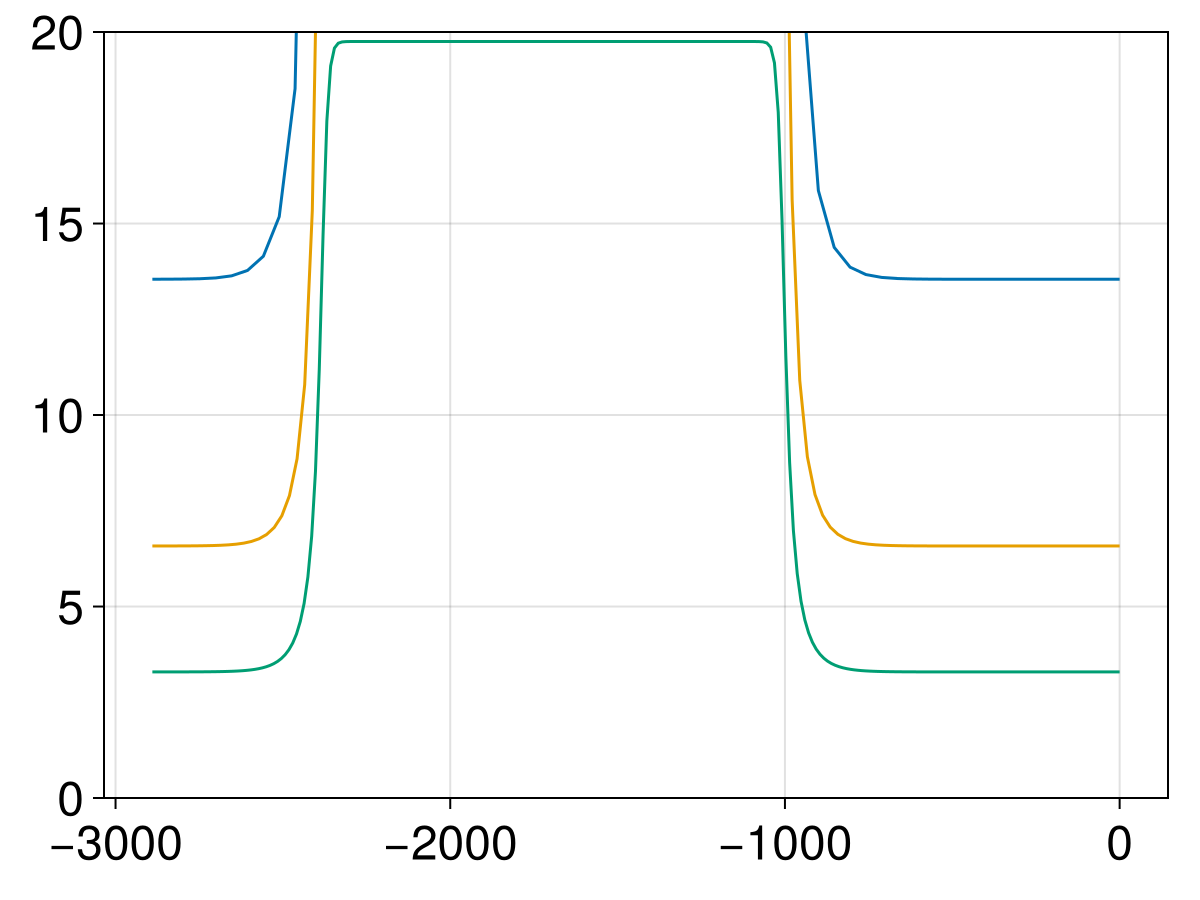

In [9]:
using CairoMakie, GeoParams
thickness = 2890 * km
η0 = 9.8e21
CharDim = GEO_units(; length = thickness, viscosity = η0, temperature = 2.800e3K)

f = Figure(fontsize=24)
ax = Axis(f[1,1])
for dx_nd in dx
    x_nd   = LinRange(-1, 0, length(dx_nd))
    x_dim  = @dimstrip(x_nd, km, CharDim)
    dx_dim = @dimstrip(dx_nd, km, CharDim)
    lines!(ax, x_dim, dx_dim)
end
ylims!(ax, 0, 20)
f

In [13]:
dx_dim = [@dimstrip(dx, km, CharDim) for dx in dx]
minimum.(dx_dim)

3-element Vector{Float64}:
 13.544212716335556
  6.579902858105809
  3.2919826954243785